# Imports

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
 
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

# Data Reading and Exploration

In [6]:
train=pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')

In [7]:
train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,

In [8]:
test=pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')

In [9]:
test.columns.shape[0]

81

In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [11]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

Text(0.5, 1.0, 'Distribution of Sale Price')

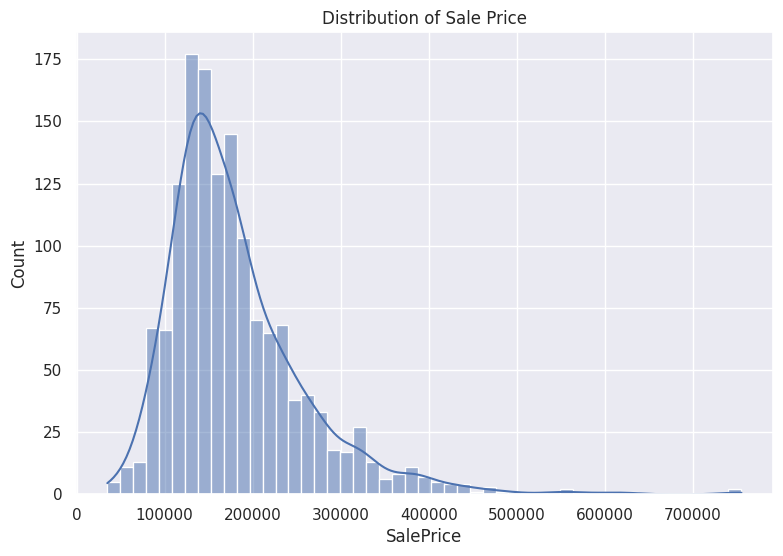

In [12]:
plt.figure(figsize=(9, 6))
sns.set(style='darkgrid')
sns.histplot(x=train["SalePrice"],kde=True)
plt.title("Distribution of Sale Price")

# Data Pre-Processing

## Missing Data

In [13]:
def percent_missing(df):
    percent_nan = 100* df.isnull().sum() / len(df)
    percent_nan = percent_nan[percent_nan>0].sort_values()
    return percent_nan
    
percent_nan_train=percent_missing(train)
percent_nan_train

Electrical       0.068493
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
BsmtExposure     2.602740
BsmtFinType2     2.602740
GarageCond       5.547945
GarageQual       5.547945
GarageFinish     5.547945
GarageYrBlt      5.547945
GarageType       5.547945
LotFrontage     17.739726
FireplaceQu     47.260274
MasVnrType      59.726027
Fence           80.753425
Alley           93.767123
MiscFeature     96.301370
PoolQC          99.520548
dtype: float64

In [14]:
percent_missing(test)

Electrical       0.068493
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
BsmtExposure     2.602740
BsmtFinType2     2.602740
GarageCond       5.547945
GarageQual       5.547945
GarageFinish     5.547945
GarageYrBlt      5.547945
GarageType       5.547945
LotFrontage     17.739726
FireplaceQu     47.260274
MasVnrType      59.726027
Fence           80.753425
Alley           93.767123
MiscFeature     96.301370
PoolQC          99.520548
dtype: float64

In [15]:
train_drop = ['Fence', 'Alley', 'MiscFeature', 'PoolQC', 'Id','MasVnrType']
train = train.drop(train_drop, axis=1,)

In [16]:
test_drop = ['Fence', 'Alley', 'MiscFeature', 'PoolQC', 'Id','MasVnrType']
test_id=test['Id']
test = test.drop(test_drop, axis=1)

In [17]:
percent_missing(train)

Electrical       0.068493
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
BsmtExposure     2.602740
BsmtFinType2     2.602740
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
LotFrontage     17.739726
FireplaceQu     47.260274
dtype: float64

In [18]:
percent_missing(test)

Electrical       0.068493
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
BsmtExposure     2.602740
BsmtFinType2     2.602740
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
LotFrontage     17.739726
FireplaceQu     47.260274
dtype: float64

In [19]:
def fill_missing(df):
    for column in df.columns:
        if df[column].dtype == 'object':
            df[column] = df[column].fillna(df[column].mode()[0])
        elif df[column].dtype in ['int64', 'float64']:  
            df[column] = df[column].fillna(df[column].median())
    return df

In [20]:
train=fill_missing(train)
test=fill_missing(test)

In [21]:
print(train.isnull().sum().sum())
print(test.isnull().sum().sum())

0
0


In [22]:
len(train.columns)

75

In [23]:
len(test.columns)

75

## Outliers

In [24]:
Q1 = train['SalePrice'].quantile(0.25)
Q3 = train['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

train['SalePrice'] = train['SalePrice'].clip(lower=lower_bound, upper=upper_bound)
print(train['SalePrice'].describe())

count      1460.000000
mean     177331.526370
std       67205.835915
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      340037.500000
Name: SalePrice, dtype: float64


<Axes: >

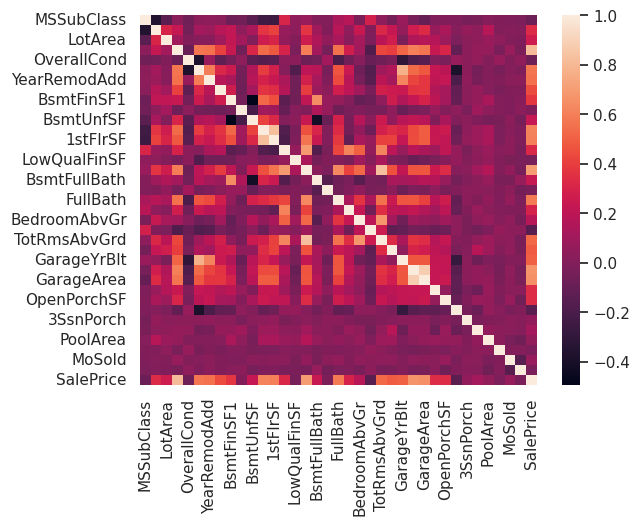

In [25]:
sns.heatmap(train.select_dtypes(include=['float64', 'int64']).corr())

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

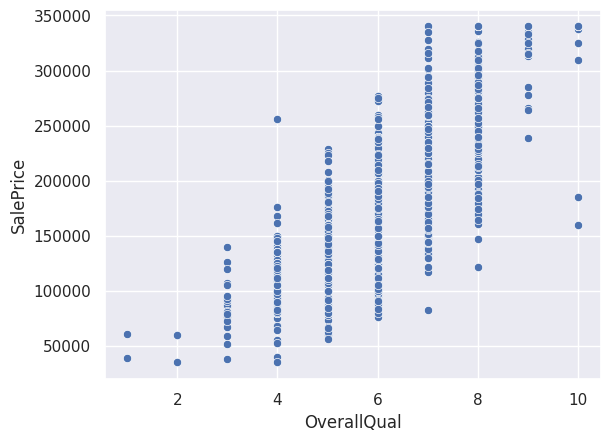

In [26]:
sns.scatterplot(x="OverallQual",y="SalePrice",data=train)

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

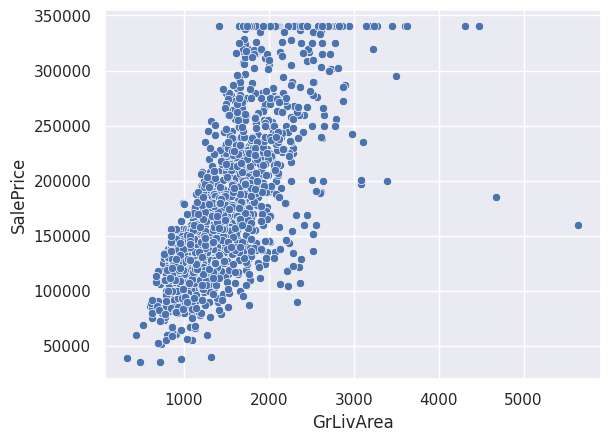

In [27]:
sns.scatterplot(x="GrLivArea",y="SalePrice",data=train)

In [28]:
outliers=train[(train["GrLivArea"]>4000) & (train["SalePrice"]<200000) ]
drop_index=outliers.index

train=train.drop(drop_index,axis=0)

## Feature Engineering

In [29]:
train.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces',
       'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish',
       'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive',
       'WoodDeckSF', 'OpenPorchSF

In [30]:
test.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces',
       'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish',
       'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive',
       'WoodDeckSF', 'OpenPorchSF

In [31]:
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
train['HasPool'] = train['PoolArea'].apply(lambda x: 1 if x > 0 else 0)
train['IsNew'] = (train['YearBuilt'] == train['YrSold']).astype(int)
train['IsNew'] = (train['YearBuilt'] == train['YrSold']).astype(int)

In [32]:
test['TotalSF'] = test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']
test['HasPool'] = test['PoolArea'].apply(lambda x: 1 if x > 0 else 0)
test['IsNew'] = (test['YearBuilt'] == test['YrSold']).astype(int)
test['IsNew'] = (test['YearBuilt'] == test['YrSold']).astype(int)

# Encoding

In [33]:
one_hot_cols = ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 
                 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 
                 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 
                 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 
                 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 
                 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 
                 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 
                 'PavedDrive', 'SaleType', 'SaleCondition']

In [34]:
combined = pd.concat([train, test], axis=0)
# Perform one-hot encoding
combined_encoded = pd.get_dummies(combined, columns=one_hot_cols)

# Split back into train and test
train = combined_encoded.iloc[:len(train), :]
test = combined_encoded.iloc[len(train):, :]
print(train.shape)
print(test.shape)

(1458, 275)
(1460, 275)


In [35]:
train.columns.shape[0]

275

In [36]:
test.columns.shape[0]

275

In [37]:
train['SalePrice']

0       208500.0
1       181500.0
2       223500.0
3       140000.0
4       250000.0
          ...   
1455    175000.0
1456    210000.0
1457    266500.0
1458    142125.0
1459    147500.0
Name: SalePrice, Length: 1458, dtype: float64

In [38]:
test=test.drop('SalePrice',axis=1)
test.shape[1]

274

# ML

## Data Splitting

In [39]:
X = train.drop('SalePrice',axis=1)
y = train['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Data Scaling

In [40]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [41]:
test=scaler.transform(test)

## Random Forest

In [42]:
"""rf_model = RandomForestRegressor(random_state=17)

rf_params = {"max_depth": [5, 8, None],
             "max_features": [3, 5, 7, "auto"],
             "min_samples_split": [2, 5, 8, 15, 20],
             "n_estimators": [100, 200, 500]
             }

rf_best_grid = GridSearchCV(estimator=rf_model,
                            param_grid=rf_params,
                            scoring='neg_mean_absolute_error',  
                            cv=5, 
                            verbose=True,
                            n_jobs=-1)
rf_best_grid.fit(X_train, y_train)"""

'rf_model = RandomForestRegressor(random_state=17)\n\nrf_params = {"max_depth": [5, 8, None],\n             "max_features": [3, 5, 7, "auto"],\n             "min_samples_split": [2, 5, 8, 15, 20],\n             "n_estimators": [100, 200, 500]\n             }\n\nrf_best_grid = GridSearchCV(estimator=rf_model,\n                            param_grid=rf_params,\n                            scoring=\'neg_mean_absolute_error\',  \n                            cv=5, \n                            verbose=True,\n                            n_jobs=-1)\nrf_best_grid.fit(X_train, y_train)'

Best Params: {'max_depth': None,
 'max_features': 7,
 'min_samples_split': 2,
 'n_estimators': 500} 

In [43]:
rf_model = RandomForestRegressor(random_state=17,max_features=7,n_estimators=500,min_samples_split=2)
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_features=7, n_estimators=500, random_state=17)

In [44]:
y_pred= rf_model.predict(X_test)

In [45]:
mse = mean_squared_error(y_test, y_pred)
mae=mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

Mean Absolute Error (MAE): 16057.43523287671
Root Mean Squared Error (RMSE): 23104.51765819729
R-squared (R2): 0.8815482319913543


## XGBoost

In [46]:
"""xgboost_model = XGBRegressor(random_state=42, eval_metric='rmse')
xgboost_params = {"learning_rate": [0.1, 0.01, 0.001],
                  "max_depth": [5, 8, None],
                  "n_estimators": [100, 500, 1000],
                  "colsample_bytree": [None, 0.7, 1]}

xgboost_best_grid = GridSearchCV(
    xgboost_model,
    xgboost_params,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=True
)
xgboost_best_grid.fit(X_train, y_train)"""

'xgboost_model = XGBRegressor(random_state=42, eval_metric=\'rmse\')\nxgboost_params = {"learning_rate": [0.1, 0.01, 0.001],\n                  "max_depth": [5, 8, None],\n                  "n_estimators": [100, 500, 1000],\n                  "colsample_bytree": [None, 0.7, 1]}\n\nxgboost_best_grid = GridSearchCV(\n    xgboost_model,\n    xgboost_params,\n    cv=5,\n    scoring=\'neg_mean_squared_error\',\n    n_jobs=-1,\n    verbose=True\n)\nxgboost_best_grid.fit(X_train, y_train)'

Best Params: {'colsample_bytree': None,
 'learning_rate': 0.1,
 'max_depth': 5,
 'n_estimators': 100}

In [47]:
xgboost_model = XGBRegressor(random_state=42, eval_metric='rmse',colsample_bytree=None, learning_rate=0.1
                            ,max_depth=5, n_estimators=100)
xgboost_model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [48]:
y_pred = xgboost_model.predict(X_test)

In [49]:
mse = mean_squared_error(y_test, y_pred)
mae=mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

Mean Absolute Error (MAE): 13135.937125428081
Root Mean Squared Error (RMSE): 18379.87349316055
R-squared (R2): 0.9250394489808006


## Gradient Boosting

In [50]:
"""gbr = GradientBoostingRegressor()

param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
}

grid_search = GridSearchCV(estimator=gbr, Aparam_grid=param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1)


grid_search.fit(X_train, y_train)"""

"gbr = GradientBoostingRegressor()\n\nparam_grid = {\n    'n_estimators': [50, 100, 150],\n    'learning_rate': [0.01, 0.1, 0.2],\n    'max_depth': [3, 4, 5],\n    'min_samples_split': [2, 5, 10],\n}\n\ngrid_search = GridSearchCV(estimator=gbr, Aparam_grid=param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1)\n\n\ngrid_search.fit(X_train, y_train)"

Best Params: {'learning_rate': 0.1,
 'max_depth': 3,
 'min_samples_split': 5,
 'n_estimators': 150}

In [51]:
gbr_model=GradientBoostingRegressor(learning_rate=0.1,max_depth=3,min_samples_split=5,n_estimators=150)
gbr_model.fit(X_train,y_train)

GradientBoostingRegressor(min_samples_split=5, n_estimators=150)

In [52]:
y_pred = gbr_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae=mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("R-squared (R2):", r2)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

R-squared (R2): 0.9336688952697108
Mean Absolute Error (MAE): 12502.36355864775
Root Mean Squared Error (RMSE): 17289.592120104626


In [54]:
predictions = gbr_model.predict(test)
submission = pd.DataFrame({'Id': test_id, 'SalePrice': predictions})
submission.to_csv('submission.csv', index=False)